Лабораторная работа №8
«Деревья решений».

Для решения задачи кредитного скоринга рассмотрите данные файла CreditSample.txt. В файле указаны данные 149 клиентов некоторого банка. Решение о выдаче кредита данным клиентам указано в последнем, целевом признаке.

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder

## 1. Загрузка данных

In [32]:
df = pd.read_csv('CreditSample.txt', delimiter='\t')
df.to_csv('CreditSample.csv', index=False, encoding='utf-8')
df.head()

,Код,№ Паспорта,ФИО,Адрес,"Размер ссуды, руб","Срок ссуды, мес",Цель ссуды,"Среднемесячный доход, руб","Среднемесячный расход, руб",Основное направление расходов,...,"Срок работы на данном предприятии, лет",Направление деятельности заемщика,"Срок работы на данном направлении, лет",Пол,Семейное положение,Количество лет,Количество иждивенцев,"Срок проживания в данной местности, лет",Обеспеченность займа,Давать кредит
0,1,0936-866096,1,1,10000,12,Покупка товара,4500,3000,Покупка товаров длит. пользования,...,6,Реклама и маркетинг,8,Жен,Да,41,3,24,ИСТИНА,ИСТИНА
1,2,8355-512943,1,1,14000,12,Оплата за образование,8500,3000,Покупка и ремонт недвижимости,...,10,Адм.-хоз. и транспортная службы,12,Жен,Нет,26,0,20,ИСТИНА,ИСТИНА
2,3,8017-098471,1,1,25000,18,Оплата за образование,7000,4000,Затраты на образование (в т.ч. детей),...,8,Участие в основной деятельности,8,Жен,Да,32,3,13,ИСТИНА,ИСТИНА
3,4,2762-945535,1,1,64000,48,Покупка и ремонт недвижимости,7000,5000,Покупка товаров длит. пользования,...,9,Участие в основной деятельности,11,Муж,Нет,50,2,22,ИСТИНА,ИСТИНА
4,5,0459-997701,1,1,3500,6,Покупка товара,3000,1500,"Содержание/аренда недвижимости, а/т",...,7,Участие в основной деятельности,8,Муж,Да,30,0,14,ИСТИНА,ЛОЖЬ


## 2. Решение проблемы категориальных признаков

In [33]:
df = df.drop(columns=['Код', '№ Паспорта', 'ФИО', 'Адрес', 'Название организации'])

In [34]:
df['Пол'] = df['Пол'].map({'Жен': 0, 'Муж': 1})
df['Наличие недвижимости'] = df['Наличие недвижимости'].map({'Да': 1, 'Нет': 0})
df['Наличие автотранспорта'] = df['Наличие автотранспорта'].map({'Да': 1, 'Нет': 0})
df['Наличие банковского счета'] = df['Наличие банковского счета'].map({'Да': 1, 'Нет': 0})
df['Наличие страховки'] = df['Наличие страховки'].map({'Да': 1, 'Нет': 0})
df['Семейное положение'] = df['Семейное положение'].map({'Да': 1, 'Нет': 0})
df['Обеспеченность займа'] = df['Обеспеченность займа'].map({'ИСТИНА': 1, 'ЛОЖЬ': 0})
df['Давать кредит'] = df['Давать кредит'].map({'ИСТИНА': 1, 'ЛОЖЬ': 0})

In [35]:
df.head()

,"Размер ссуды, руб","Срок ссуды, мес",Цель ссуды,"Среднемесячный доход, руб","Среднемесячный расход, руб",Основное направление расходов,Наличие недвижимости,Наличие автотранспорта,Наличие банковского счета,Наличие страховки,...,"Срок работы на данном предприятии, лет",Направление деятельности заемщика,"Срок работы на данном направлении, лет",Пол,Семейное положение,Количество лет,Количество иждивенцев,"Срок проживания в данной местности, лет",Обеспеченность займа,Давать кредит
0,10000,12,Покупка товара,4500,3000,Покупка товаров длит. пользования,1,1,0,0,...,6,Реклама и маркетинг,8,0,1,41,3,24,1,1
1,14000,12,Оплата за образование,8500,3000,Покупка и ремонт недвижимости,1,1,0,0,...,10,Адм.-хоз. и транспортная службы,12,0,0,26,0,20,1,1
2,25000,18,Оплата за образование,7000,4000,Затраты на образование (в т.ч. детей),1,1,0,0,...,8,Участие в основной деятельности,8,0,1,32,3,13,1,1
3,64000,48,Покупка и ремонт недвижимости,7000,5000,Покупка товаров длит. пользования,1,1,0,0,...,9,Участие в основной деятельности,11,1,0,50,2,22,1,1
4,3500,6,Покупка товара,3000,1500,"Содержание/аренда недвижимости, а/т",0,1,0,0,...,7,Участие в основной деятельности,8,1,1,30,0,14,1,0


Решение проблем с нечисловыми категориальными признаками, используя OneHotEncoder

In [36]:
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded_columns = encoder.fit_transform(df[non_numeric_columns])

encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(non_numeric_columns))

df = df.drop(non_numeric_columns, axis=1)
df = pd.concat([df, encoded_df], axis=1)

/Users/zeto/Projects/university/5sem/mitmo/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [37]:
df.head()

,"Размер ссуды, руб","Срок ссуды, мес","Среднемесячный доход, руб","Среднемесячный расход, руб",Наличие недвижимости,Наличие автотранспорта,Наличие банковского счета,Наличие страховки,"Срок работы на данном предприятии, лет","Срок работы на данном направлении, лет",...,Направление деятельности заемщика_Адм.-хоз. и транспортная службы,"Направление деятельности заемщика_Бухгалтерия, финансы и планирование",Направление деятельности заемщика_Вспомогательный технический персонал,Направление деятельности заемщика_Кадровая служба и секритариат,Направление деятельности заемщика_Пр.-техн. обесп. и телекомуникации,Направление деятельности заемщика_Реклама и маркетинг,Направление деятельности заемщика_Служба безопасности,Направление деятельности заемщика_Снабжение и сбыт,Направление деятельности заемщика_Участие в основной деятельности,Направление деятельности заемщика_Юридическая служба
0,10000,12,4500,3000,1,1,0,0,6,8,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,14000,12,8500,3000,1,1,0,0,10,12,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25000,18,7000,4000,1,1,0,0,8,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,64000,48,7000,5000,1,1,0,0,9,11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3500,6,3000,1500,0,1,0,0,7,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [38]:
df.to_csv('CreditSampleNormalize.csv', index=False, encoding='utf-8')

## 3. Сравнение доли каждого из классов

In [39]:
for class_type in df.columns:
    print(df[class_type].value_counts(normalize=True), end='\n\n')

Размер ссуды, руб
13500    0.046980
14000    0.040268
4000     0.033557
16500    0.033557
39000    0.033557
           ...   
41000    0.006711
4500     0.006711
7000     0.006711
51500    0.006711
14500    0.006711
Name: proportion, Length: 73, dtype: float64

Срок ссуды, мес
12    0.395973
6     0.275168
18    0.221477
24    0.060403
30    0.020134
42    0.013423
48    0.006711
36    0.006711
Name: proportion, dtype: float64

Среднемесячный доход, руб
6000     0.073826
9000     0.067114
7000     0.067114
11000    0.067114
13000    0.053691
9500     0.053691
7500     0.046980
8000     0.046980
5500     0.046980
11500    0.040268
8500     0.040268
12500    0.040268
6500     0.033557
10500    0.026846
3500     0.026846
4000     0.020134
13500    0.020134
15000    0.020134
4500     0.020134
15500    0.020134
2500     0.020134
14000    0.013423
16000    0.013423
16500    0.013423
3000     0.013423
5000     0.013423
10000    0.013423
22500    0.006711
17500    0.006711
18000    0.006711
20

## 4. Разбиение выборки на обучающую и тестовую

In [40]:
X = df.drop('Давать кредит', axis=1)
y = df['Давать кредит']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [41]:
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((104, 71), (45, 71), (104,), (45,))

## 5. Построение классификатора, реализующего метод дерева решений
Описание задания:
Постройте классификатор, реализующий метод дерева решений. В качестве критерия разбиения возьмите критерий информативности. Реализуйте оба способа оценки информативности (индекс Джинни и энтропию Шеннона – выбор через гиперпараметр классификатора). 

### Классификатор с критерием информативности Джинни

In [42]:
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

gini_predictions = clf_gini.predict(X_test)
gini_accuracy = accuracy_score(y_test, gini_predictions)
gini_report = classification_report(y_test, gini_predictions)

print(f'Точность: {gini_accuracy}')
print(gini_report)

Точность: 0.6222222222222222
              precision    recall  f1-score   support

           0       0.20      0.18      0.19        11
           1       0.74      0.76      0.75        34

    accuracy                           0.62        45
   macro avg       0.47      0.47      0.47        45
weighted avg       0.61      0.62      0.62        45


#### Анализ результатов классификатора с критерием информативности Джинни 

Общая точность модели составляет 62.22%. Модель демонстрирует значительно более высокую точность (precision), полноту (recall) и F1-балл в предсказании класса "Дали кредит" (1) по сравнению с классом "Не дали кредит" (0), что указывает на её лучшую способность корректно идентифицировать случаи выдачи кредита.

### Классификатор с энтропией Шеннона.

In [43]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

entropy_predictions = clf_entropy.predict(X_test)
entropy_accuracy = accuracy_score(y_test, entropy_predictions)
entropy_report = classification_report(y_test, entropy_predictions)

print(f'Точность: {entropy_accuracy}')
print(entropy_report)

Точность: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.60      0.27      0.37        11
           1       0.80      0.94      0.86        34

    accuracy                           0.78        45
   macro avg       0.70      0.61      0.62        45
weighted avg       0.75      0.78      0.75        45


#### Анализ результатов классификатора с энтропией Шеннона.

В сравнении с первым анализом, где использовался критерий Джинни, модель дерева решений с критерием энтропии Шеннона показала значительно лучшие результаты.

Общая точность модели увеличилась с 62.22% до 77.78%, что свидетельствует о более высокой эффективности в классификации. Особенно заметно улучшение в точности и полноте предсказания для класса "Дали кредит" (1), а также уменьшение разрыва в производительности между классами "Дали кредит" и "Не дали кредит". Это указывает на более сбалансированную и точную классификацию при использовании энтропии Шеннона.

### 6. Обучение с использованием гиперпараметров 

In [44]:
criteria = ['gini', 'entropy']
max_depths = [3, 5, 7, None]
min_samples_leaf = [1, 5, 10]

results = []

for criterion in criteria:
    for max_depth in max_depths:
        for min_sample_leaf in min_samples_leaf:
            model = DecisionTreeClassifier(criterion=criterion, 
                                           max_depth=max_depth, 
                                           min_samples_leaf=min_sample_leaf,
                                           random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            results.append({"Criterion": criterion, 'Max Depth': max_depth, 'Min Samples Leaf': min_sample_leaf, 'Accuracy': accuracy})

sorted_results = sorted(results, key=lambda x: x['Accuracy'], reverse=True)
results_refined = pd.DataFrame(sorted_results)
results_refined.head(10)

,Criterion,Max Depth,Min Samples Leaf,Accuracy
0,gini,5.0,10,0.800000
1,gini,7.0,10,0.800000
2,gini,NaN,10,0.800000
3,entropy,5.0,10,0.800000
4,entropy,7.0,10,0.800000
5,entropy,NaN,10,0.800000
6,gini,5.0,5,0.777778
7,entropy,5.0,5,0.777778
8,entropy,NaN,1,0.777778
9,gini,3.0,5,0.755556


#### Анализ результатов моделей дерева решений с различными гиперпараметрами

Максимальная точность 80% достигается при использовании как индекса Джинни, так и энтропии Шеннона, при этом наилучшие результаты наблюдаются при максимальной глубине дерева 5-7 и минимальном количестве объектов в листе от 1 до 5. Эти данные свидетельствуют о высокой эффективности деревьев решений для классификации в данном наборе данных, демонстрируя хорошее разделение классов и устойчивость к переобучению.

## Дополнительно

Найдите возможность визуализации дерева решений (функция `export_graphviz` из `graphviz` в комплекте с `pydotplus`). 
Реализуйте визуализацию одного из вариантов полученных деревьев.

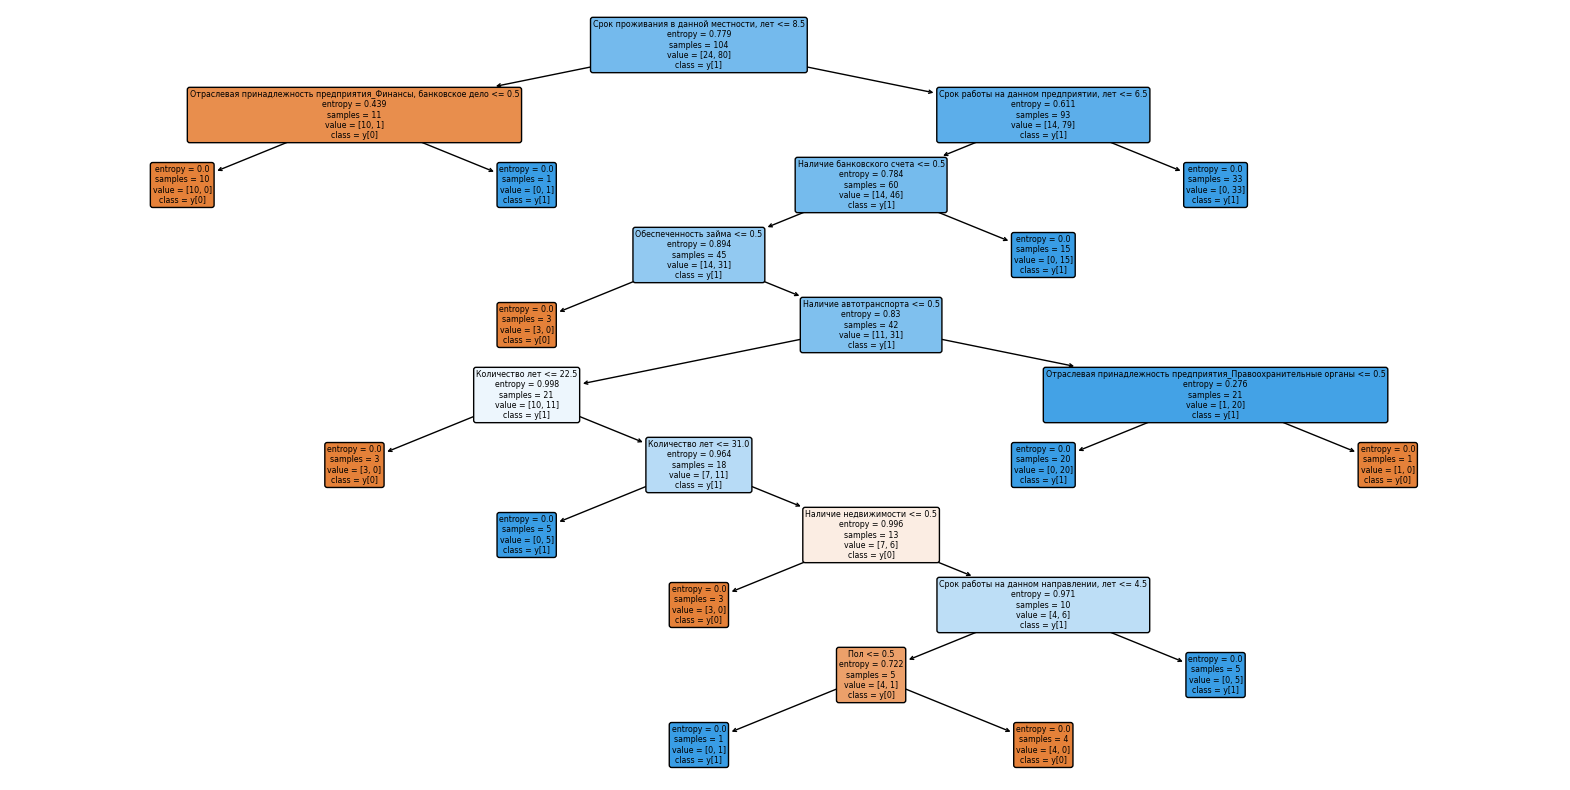

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(clf_entropy, filled=True, rounded=True, class_names=True, feature_names=X_train.columns)
plt.show()

Судя по визуализации, основной вес на решение имеет срок проживания, срок работы на предприятии и отраслевая принадлежность